# Gas Expansion with `ViscousEulerSPH`

This tutorial solves Euler-type fluid dynamics with SPH using the `ViscousEulerSPH` model. The continuum equations are

$$
\begin{aligned}
 \partial_t \rho + \nabla \cdot (\rho \mathbf u) &= 0\,,
 \\[2mm]
 \rho(\partial_t \mathbf u + \mathbf u \cdot \nabla \mathbf u) &= - \nabla \left(\rho^2 \frac{\partial \mathcal U(\rho, S)}{\partial \rho} \right)\,,
 \\[2mm]
 \partial_t S + \mathbf u \cdot \nabla S &= 0\,.
\end{aligned}
$$

Here, $S$ is entropy per unit mass and the internal energy model is

$$
\mathcal U(\rho, S) = \kappa(S)\log\rho\,.
$$

After SPH discretization, particle trajectories satisfy

$$
\begin{aligned}
 \dot{\mathbf x}_p &= \mathbf v_p\,,\qquad && \mathbf x_p(0) = \mathbf x_{p0}\,,
 \\[2mm]
 \dot{\mathbf v}_p &= -\kappa_p(0) \sum_{i=1}^N w_i \left(\frac{1}{\rho^{N,h}(\mathbf x_p)} + \frac{1}{\rho^{N,h}(\mathbf x_i)} \right) \nabla W_h(\mathbf x_p-\mathbf x_i)\,,
\end{aligned}
$$

with smoothed density

$$
\rho^{N,h}(\mathbf x)=\sum_{j=1}^N w_j W_h(\mathbf x-\mathbf x_j)\,.
$$

In Struphy, the pressure-driven velocity update is handled by `PushVinSPHpressure`.

Before launching the full gas-expansion case, let us quickly inspect a few available smoothing kernels.

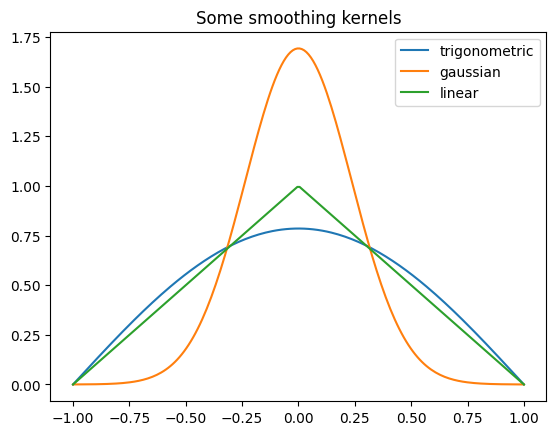

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from struphy.pic.sph_smoothing_kernels import gaussian_uni, linear_uni, trigonometric_uni

x = np.linspace(-1, 1, 200)
out1 = np.zeros_like(x)
out2 = np.zeros_like(x)
out3 = np.zeros_like(x)

for i, xi in enumerate(x):
    out1[i] = trigonometric_uni(xi, 1.0)
    out2[i] = gaussian_uni(xi, 1.0)
    out3[i] = linear_uni(xi, 1.0)
plt.plot(x, out1, label="trigonometric")
plt.plot(x, out2, label="gaussian")
plt.plot(x, out3, label="linear")
plt.title("Some smoothing kernels")
plt.legend()

### Step 1: Import APIs and the `ViscousEulerSPH` Model

Load all Struphy components and plotting utilities needed for this standalone gas-expansion tutorial.

In [2]:
from struphy import DerhamOptions, EnvironmentOptions, Time
from struphy import domains
from struphy import equils
from struphy import grids
from struphy import (
    BinningPlot,
    BoundaryParameters,
    KernelDensityPlot,
    LoadingParameters,
    SavingParameters,
    SortingParameters,
    WeightsParameters,
)
from struphy import Simulation

# import model
from struphy.models import ViscousEulerSPH

Let us verfiy the model equations by calling the `pde` method:

In [3]:
ViscousEulerSPH.pde()

### Step 2: Define Environment and Domain

Set time step, final time, and simulation domain. These settings are tuned for a 2D expansion embedded in a cuboid geometry.

In [4]:
# environment options
env = EnvironmentOptions()

# time stepping
time_opts = Time(dt=0.04, Tend=1.6, split_algo="Strang")

# geometry
l1 = -3.0
r1 = 3.0
l2 = -3.0
r2 = 3.0
l3 = 0.0
r3 = 1.0
domain = domains.Cuboid(l1=l1, r1=r1, l2=l2, r2=r2, l3=l3, r3=r3)

### Step 3: Build the Initial Density Blob

Define a Gaussian density profile in the $(x,y)$ plane and wrap it as a fluid equilibrium object. This serves as the initial condition for the expansion.

In [5]:
# gaussian initial blob
import numpy as np

T_h = 0.2
gamma = 5 / 3
n_fun = lambda x, y, z: np.exp(-(x**2 + y**2) / T_h) / 35

blob = equils.GenericCartesianFluidEquilibrium(n_xyz=n_fun)

### Step 4: Set Grid and de Rham Discretization

Choose the spline grid and de Rham options used by the field projections in this SPH run.

In [6]:
# fluid equilibrium (can be used as part of initial conditions)
equil = None

# grid
grid = grids.TensorProductGrid(num_elements=(64, 64, 1))

# derham options
bcs = (("free", "free"), ("free", "free"), None)
derham_opts = DerhamOptions(degree=(3, 3, 1), bcs=bcs)

### Step 5: Instantiate `ViscousEulerSPH` and Simulation

Create a lightweight model with magnetic-background and viscosity terms disabled (`with_B0=False`, `with_viscosity=False`), then build the simulation object.

In [7]:
# light-weight model instance
model = ViscousEulerSPH(with_B0=False, with_viscosity=False)

sim = Simulation(model,
                 env=env,
                 time_opts=time_opts,
                 domain=domain,
                 equil=equil,
                 grid=grid,
                 derham_opts=derham_opts,)

### Step 6: Configure Marker Sampling

Set dense particle-per-box loading and enable `reject_weights` to discard very small particle weights. This reduces cost while preserving the dominant density structure.

In [8]:
loading_params = LoadingParameters(ppb=400)
weights_params = WeightsParameters(reject_weights=True, threshold=3e-8)
boundary_params = BoundaryParameters()
nx = 16
ny = 16
sorting_params = SortingParameters(boxes_per_dim=(nx, ny, 1))

### Step 7: Add Diagnostics for Visualization

Save both a binning plot and an SPH kernel-density plot so you can compare coarse gridded density against kernel-based reconstruction.

In [9]:
bin_plot = BinningPlot(
    slice="e1_e2",
    n_bins=(64, 64),
    ranges=((0.0, 1.0), (0.0, 1.0)),
    divide_by_jac=False,
)
pts_e1 = 100
pts_e2 = 90
kd_plot = KernelDensityPlot(pts_e1=pts_e1, pts_e2=pts_e2, pts_e3=1)

saving_params = SavingParameters(
    n_markers=1.0,
    binning_plots=(bin_plot,),
    kernel_density_plots=(kd_plot,),
)

model.euler_fluid.set_markers(
    loading_params=loading_params,
    weights_params=weights_params,
    boundary_params=boundary_params,
    sorting_params=sorting_params,
    saving_params=saving_params,
)

### Step 8: Select the SPH Kernel for Pressure Updates

For the pressure propagator, choose `gaussian_2d` as smoothing kernel. You can swap this setting later to study kernel sensitivity.

In [10]:
# propagator options
from struphy import ButcherTableau

butcher = ButcherTableau(algo="forward_euler")
model.propagators.push_eta.options = model.propagators.push_eta.Options(butcher=butcher)

model.propagators.push_sph_p.options = model.propagators.push_sph_p.Options(kernel_type="gaussian_2d")

### Step 9: Initialize, Run, and Load Results

Attach the Gaussian background and execute the standard workflow: `run()`, `pproc()`, `load_plotting_data()`.

Performance note: early time steps are typically slower because particles are highly concentrated; runtime usually improves as the cloud expands. Running from a console script (especially with MPI/GPU support) is faster than notebook execution.

In [11]:
# background, perturbations and initial conditions
model.euler_fluid.var.add_background(blob)

In [12]:
sim.run()


Starting run for model ViscousEulerSPH ...


Time stepping:   0%|          | 0/40 [00:00<?, ?step/s]

Time stepping:   2%|▎         | 1/40 [00:01<01:11,  1.83s/step]

Time stepping:   5%|▌         | 2/40 [00:03<01:08,  1.80s/step]

Time stepping:   8%|▊         | 3/40 [00:05<01:04,  1.76s/step]

...

Time stepping:  95%|█████████▌| 38/40 [00:23<00:00,  3.31step/s]

Time stepping:  98%|█████████▊| 39/40 [00:23<00:00,  3.26step/s]

Time stepping: 100%|██████████| 40/40 [00:23<00:00,  3.21step/s]

Time stepping: 100%|██████████| 40/40 [00:23<00:00,  1.67step/s]


Struphy run finished.


In [13]:
sim.pproc()


Post-processing path /home/runner/work/struphy/struphy/doc/_collections/tutorials/sim_1



No feec fields found in hdf5 file, skipping post-processing of fields.


Evaluation of 4008 marker orbits for euler_fluid


  0%|          | 0/41 [00:00<?, ?it/s]

 20%|█▉        | 8/41 [00:00<00:00, 75.18it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 930.21it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 217.78it/s]


Evaluation of sph density for euler_fluid


In [14]:
sim.load_plotting_data()


Loading post-processed plotting data:


Data path: /home/runner/work/struphy/struphy/doc/_collections/tutorials/sim_1/post_processing



The following data has been loaded:



grids:


self.t_grid.shape =(41,)


...

    euler_fluid, shape = (41, 4008, 8)
        Number of time points: 41
        Number of particles:   4008
        Number of attributes:  8



self.f:


    euler_fluid
        e1_e2_density



self.n_sph:


    euler_fluid
        view_0



### Step 10: Inspect Stored Outputs

After post-processing, use the printed paths to locate simulation artifacts. The following cells compare analytical initialization, marker sampling, SPH reconstruction, and binned density diagnostics.

In [15]:
# analytical functions
n_xyz = blob.n_xyz
n3 = blob.n3

# grids
x = np.linspace(l1, r1, pts_e1)
y = np.linspace(l2, r2, pts_e2)
xx, yy = np.meshgrid(x, y, indexing="ij")
ee1, ee2, ee3 = sim.n_sph.euler_fluid.view_0.grid_n_sph
eta1 = ee1[:, 0, 0]
eta2 = ee2[0, :, 0]
bc_x = sim.f.euler_fluid.e1_e2_density.grid_e1
bc_y = sim.f.euler_fluid.e1_e2_density.grid_e2

# markers
orbits = sim.orbits.euler_fluid
positions = orbits[0, :, :3]
weights = orbits[0, :, 6]

# binning and sph eval
n_sph = sim.n_sph.euler_fluid.view_0.n_sph[0]
f_bin = sim.f.euler_fluid.e1_e2_density.f_binned[0]

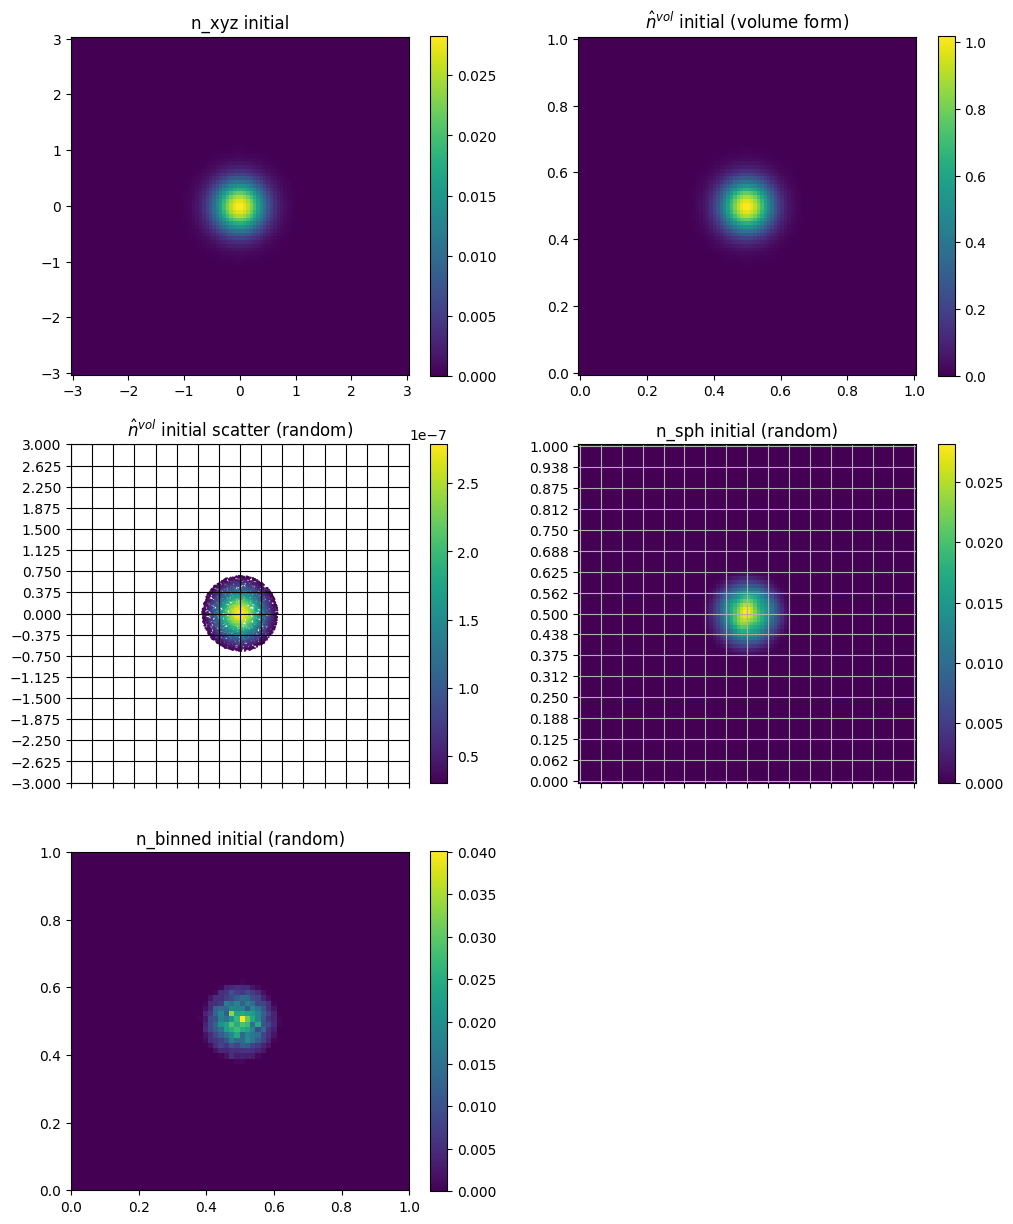

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 15))

# plots
plt.subplot(3, 2, 1)
plt.pcolor(xx, yy, n_fun(xx, yy, 0))
plt.axis("square")
plt.title("n_xyz initial")
plt.colorbar()

plt.subplot(3, 2, 2)
plt.pcolor(eta1, eta2, n3(eta1, eta2, 0, squeeze_out=True).T)
plt.axis("square")
plt.title("$\hat{n}^{\t{vol}}$ initial (volume form)")
plt.colorbar()

make_scatter = True
if make_scatter:
    plt.subplot(3, 2, 3)
    ax = plt.gca()
    ax.set_xticks(np.linspace(l1, r1, nx + 1))
    ax.set_yticks(np.linspace(l2, r2, ny + 1))
    plt.tick_params(labelbottom=False)
    coloring = weights
    plt.scatter(positions[:, 0], positions[:, 1], c=coloring, s=0.25)
    plt.grid(c="k")
    plt.axis("square")
    plt.title("$\hat{n}^{\t{vol}}$ initial scatter (random)")
    plt.xlim(l1, r1)
    plt.ylim(l2, r2)
    plt.colorbar()

plt.subplot(3, 2, 4)
ax = plt.gca()
ax.set_xticks(np.linspace(0, 1, nx + 1))
ax.set_yticks(np.linspace(0, 1.0, ny + 1))
plt.tick_params(labelbottom=False)
plt.pcolor(ee1[:, :, 0], ee2[:, :, 0], n_sph[:, :, 0])
plt.grid()
plt.axis("square")
plt.title("n_sph initial (random)")
plt.colorbar()

plt.subplot(3, 2, 5)
ax = plt.gca()
plt.pcolor(bc_x, bc_y, f_bin)
plt.axis("square")
plt.title("n_binned initial (random)")
plt.colorbar()

i=0
i=4
i=8
i=12
i=16
i=20
i=24


i=28


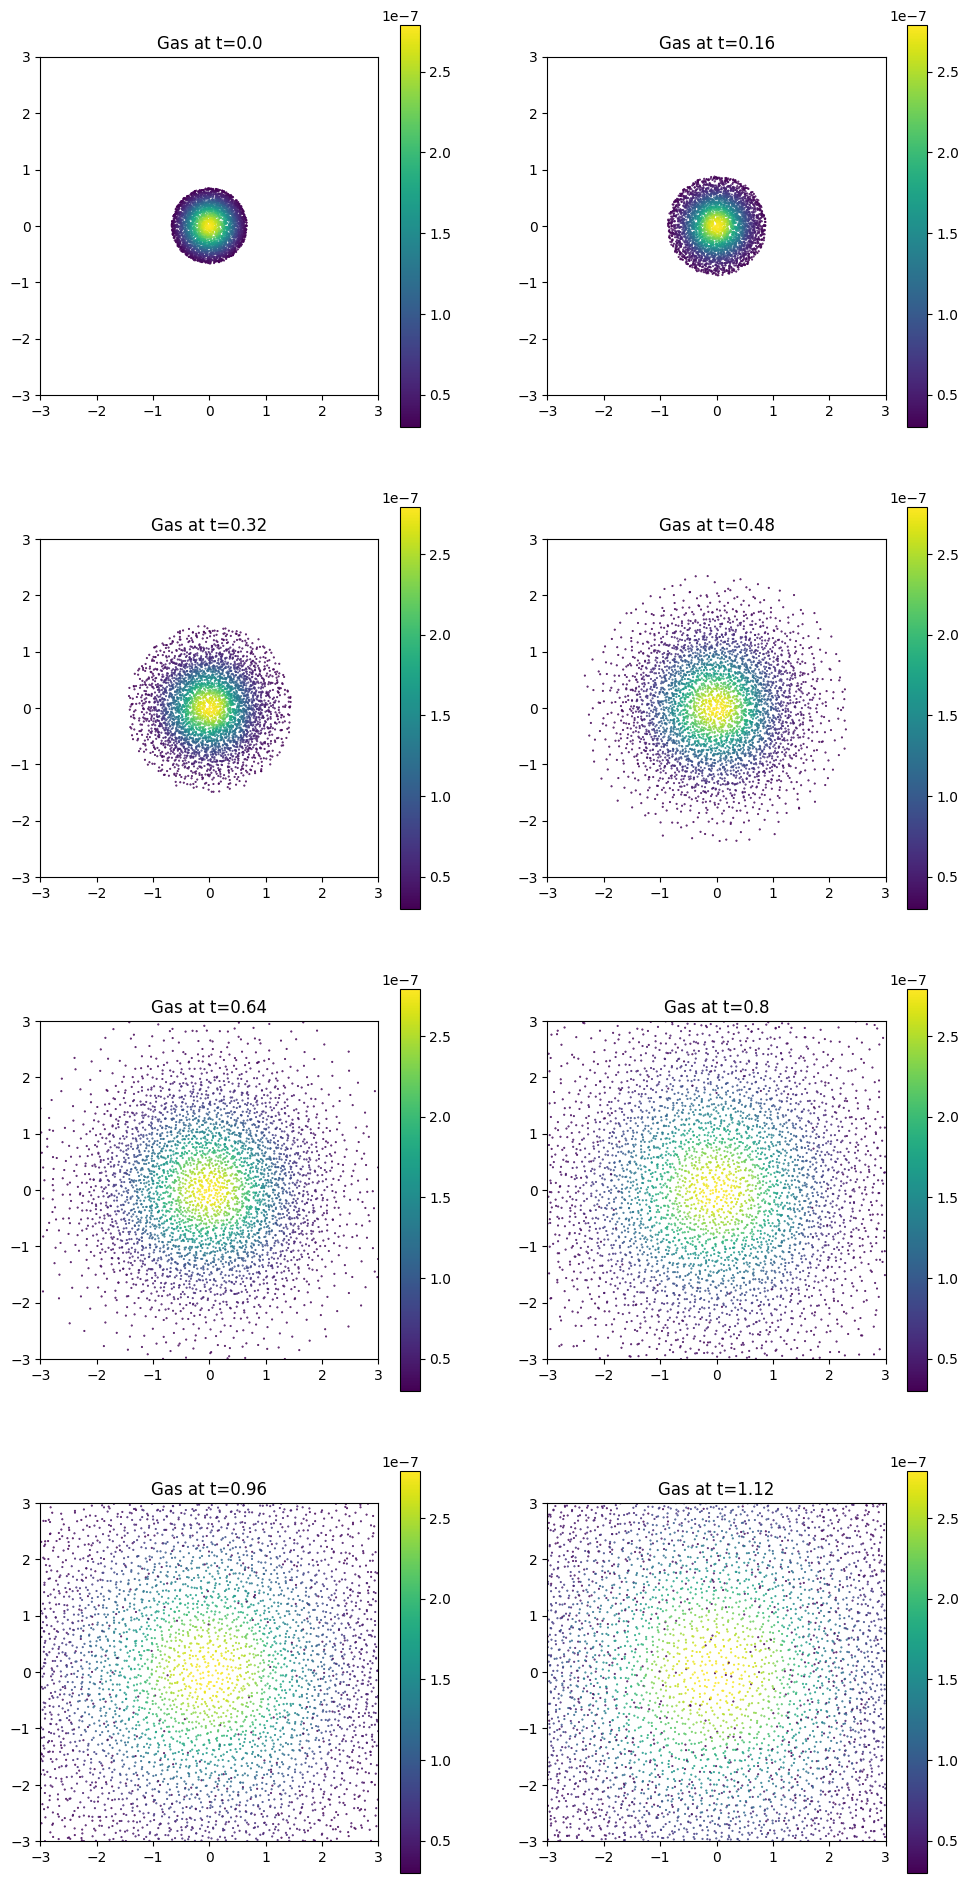

In [17]:
dt = time_opts.dt
Nt = sim.t_grid.size - 1

positions = orbits[:, :, :3]

interval = Nt / 10
plot_ct = 0

plt.figure(figsize=(12, 24))
for i in range(Nt):
    if i % interval == 0:
        print(f"{i=}")
        plot_ct += 1
        plt.subplot(4, 2, plot_ct)
        ax = plt.gca()
        coloring = weights
        plt.scatter(positions[i, :, 0], positions[i, :, 1], c=coloring, s=0.25)
        plt.axis("square")
        plt.title("n0_scatter")
        plt.xlim(l1, r1)
        plt.ylim(l2, r2)
        plt.colorbar()
        plt.title(f"Gas at t={i * dt}")
    if plot_ct == 8:
        break